# Datathon 2026

In [2]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.linear_model import LinearRegression
import datetime
import warnings
warnings.filterwarnings('ignore')

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error
import shap

# Đảm bảo thư mục lưu chart tồn tại
os.makedirs('../output/chart', exist_ok=True)


## 1. Data Loading & Preprocessing

In [4]:
# Load data
df_train = pd.read_csv('../data/sales.csv', parse_dates=['Date'])
df_train = df_train.sort_values('Date').reset_index(drop=True)

df_sub = pd.read_csv('../data/sample_submission.csv')
df_test = pd.DataFrame({'Date': pd.to_datetime(df_sub['Date'].unique())})
df_test = df_test.sort_values('Date').reset_index(drop=True)

print(f"Train dates: {df_train['Date'].min().date()} to {df_train['Date'].max().date()}")
print(f"Test dates:  {df_test['Date'].min().date()} to {df_test['Date'].max().date()}")

Train dates: 2012-07-04 to 2022-12-31
Test dates:  2023-01-01 to 2024-07-01


In [5]:
def build_features(df):
    df['year'] = df['Date'].dt.year
    df['month'] = df['Date'].dt.month
    df['day'] = df['Date'].dt.day
    df['dow'] = df['Date'].dt.dayofweek
    df['week_of_year'] = df['Date'].dt.isocalendar().week.astype(int)
    df['day_of_year'] = df['Date'].dt.dayofyear
    df['is_weekend'] = df['dow'].isin([5, 6]).astype(int)
    
    df['is_odd_year'] = (df['year'] % 2 != 0).astype(int)
    df['is_ub_window'] = df['week_of_year'].between(31, 35).astype(int)
    df['is_urban_blowout_odd'] = (df['is_odd_year'] & df['is_ub_window']).astype(int)

    if 'Revenue' in df.columns:
        df['cogs_ratio'] = df['COGS'] / df['Revenue']
        df['cogs_ratio'] = df['cogs_ratio'].clip(0.5, 2.0)

    return df

df_train = build_features(df_train)
df_test = build_features(df_test)

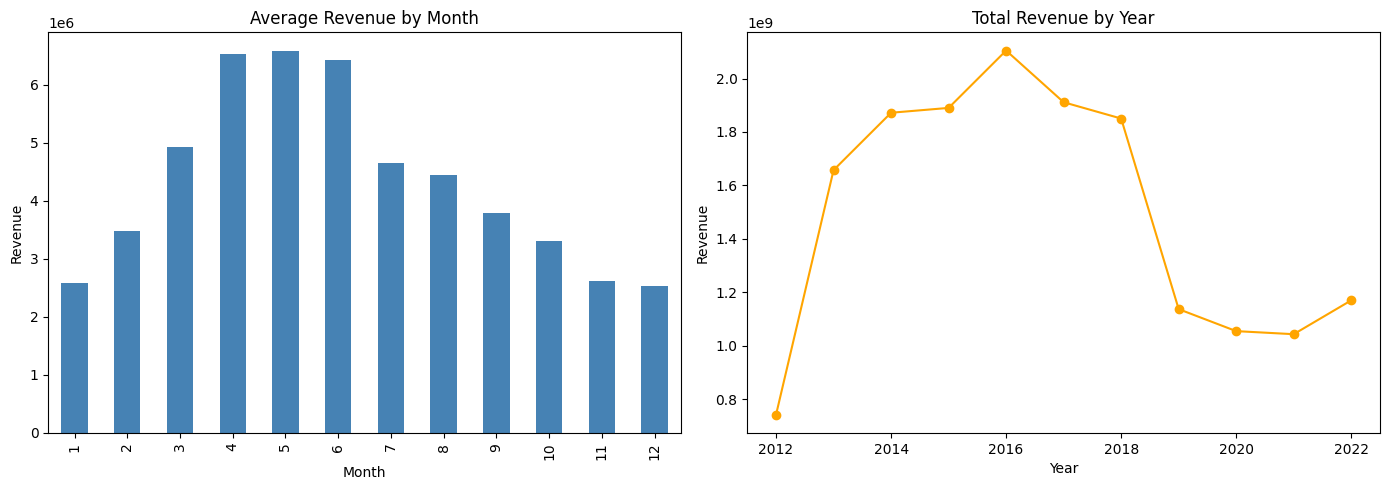

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly seasonality
df_train.groupby('month')['Revenue'].mean().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Average Revenue by Month')
axes[0].set_xlabel('Month'); axes[0].set_ylabel('Revenue')

# Yearly trend
df_train.groupby('year')['Revenue'].sum().plot(ax=axes[1], marker='o', color='orange')
axes[1].set_title('Total Revenue by Year')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Revenue')

plt.tight_layout()
plt.savefig('../output/chart/eda_seasonality.png', dpi=300)
plt.show()

In [7]:
# [Thêm cell] Cross-Validation trên Train Data (giải thích cho report, không vào df_test)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

def rmse(y_true, y_pred): 
    return np.sqrt(mean_squared_error(y_true, y_pred))

tscv = TimeSeriesSplit(n_splits=5)
cv_results = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(df_train)):
    train_fold = df_train.iloc[train_idx]
    val_fold   = df_train.iloc[val_idx]
    
    # Dùng đúng logic median như pipeline chính
    q50 = train_fold.groupby(['month','day'])['Revenue'].median()
    val_pred = val_fold.apply(
        lambda r: q50.get((r['month'], r['day']), train_fold['Revenue'].median()), axis=1
    )
    overall_med = val_pred.median()
    val_pred = val_pred - 0.07 * (val_pred - overall_med)
    
    mae  = mean_absolute_error(val_fold['Revenue'], val_pred)
    r    = rmse(val_fold['Revenue'], val_pred)
    cv_results.append({'fold': fold+1, 'MAE': mae, 'RMSE': r})

cv_df = pd.DataFrame(cv_results)
print(cv_df)
print(f"\nMean MAE:  {cv_df['MAE'].mean():,.0f}")
print(f"Mean RMSE: {cv_df['RMSE'].mean():,.0f}")

   fold           MAE          RMSE
0     1  1.293928e+06  1.724982e+06
1     2  1.311239e+06  1.851214e+06
2     3  1.389614e+06  1.842925e+06
3     4  1.845039e+06  2.139671e+06
4     5  1.588959e+06  1.909686e+06

Mean MAE:  1,485,756
Mean RMSE: 1,893,696


## 3. Modeling - Revenue: Mathematical Median & Shrinkage

In [8]:
q50_shape = df_train.groupby(['month', 'day'])['Revenue'].median().reset_index()
q50_shape.rename(columns={'Revenue': 'q50_baseline'}, inplace=True)

df_test = df_test.merge(q50_shape, on=['month', 'day'], how='left')
df_test['q50_baseline'] = df_test['q50_baseline'].ffill()

# SHRINKAGE 7% (Tự động co ngót)
alpha_shrink = 0.07
overall_median = df_test['q50_baseline'].median()
df_test['final_revenue'] = df_test['q50_baseline'] - alpha_shrink * (df_test['q50_baseline'] - overall_median)
df_test['final_revenue'] = df_test['final_revenue'].clip(lower=0)

print(f"Historical Median Revenue (Base): {df_test['q50_baseline'].mean():,.0f}")
print(f"Final Revenue sau Shrinkage 7%: {df_test['final_revenue'].mean():,.0f}")

Historical Median Revenue (Base): 4,487,534
Final Revenue sau Shrinkage 7%: 4,456,048


## 4. Predict COGS Ratio: LightGBM Bagging

Sử dụng kỹ thuật ensemble averaging từ 3 SEEDs (42, 7, 123) để giúp hệ thống miễn nhiễm với độ lệch seed-noise (chống overfitting).

In [9]:
features_cols = ['month', 'day', 'dow', 'week_of_year', 'day_of_year', 'is_weekend', 'is_urban_blowout_odd']
df_ml_train = df_train.dropna(subset=['cogs_ratio'])

X = df_ml_train[features_cols]
y = df_ml_train['cogs_ratio']

# Sử dụng Bagging qua nhiều Seeds để tăng cường độ ổn định
SEEDS = [42, 7, 123]
cogs_preds = []

for s in SEEDS:
    params = {
        'objective': 'regression',
        'metric': 'mae',
        'learning_rate': 0.03,
        'num_leaves': 15,
        'min_data_in_leaf': 20,
        'feature_fraction': 0.8,
        'bagging_fraction': 0.8,
        'bagging_freq': 1,
        'seed': s,
        'verbose': -1
    }
    train_data = lgb.Dataset(X, label=y)
    
    model_cogs = lgb.train(params, train_data, num_boost_round=150)
    
    preds = model_cogs.predict(df_test[features_cols])
    cogs_preds.append(preds)

df_test['pred_cogs_ratio'] = np.mean(cogs_preds, axis=0)
df_test['final_cogs'] = df_test['final_revenue'] * df_test['pred_cogs_ratio']

## 6. Format Submission Cuối Cùng

Lọc các thông tin ra chuẩn format được yêu cầu.

In [10]:
df_out = df_test[['Date', 'final_revenue', 'final_cogs']].copy()
df_out.rename(columns={'final_revenue': 'Revenue', 'final_cogs': 'COGS'}, inplace=True)
df_out['Date'] = df_out['Date'].dt.strftime('%Y-%m-%d')

# Kiểm tra nhanh sanity check
print("Trung bình Revenue 2023:", df_out[df_out['Date'].str.startswith('2023')]['Revenue'].mean())
print("Trung bình cogs_ratio:", (df_out['COGS'] / df_out['Revenue']).mean())
print("\n--- Sample Output ---")
print(df_out.head())

df_out.to_csv('../output/submission.csv', index=False)

Trung bình Revenue 2023: 4219994.059871439
Trung bình cogs_ratio: 0.8754123735062045

--- Sample Output ---
         Date       Revenue          COGS
0  2023-01-01  4.037690e+06  3.634815e+06
1  2023-01-02  1.851539e+06  1.551612e+06
2  2023-01-03  1.400827e+06  1.151174e+06
3  2023-01-04  1.491200e+06  1.224209e+06
4  2023-01-05  1.711718e+06  1.381652e+06


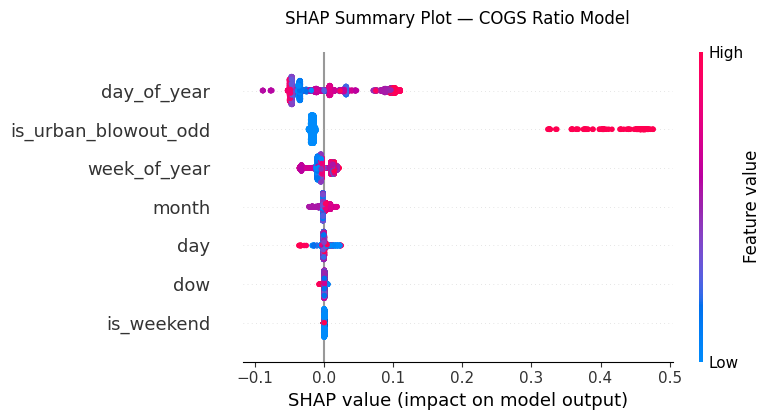

In [13]:
# [Thêm cell] SHAP trên model cogs_ratio đã train ở trên
import shap

# Lấy model_cogs (model cuối cùng trong vòng lặp SEEDS) và data X đã dùng để train cogs_ratio
explainer_ratio = shap.TreeExplainer(model_cogs)
shap_values_ratio = explainer_ratio.shap_values(X)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_ratio, X, show=False)
plt.title('SHAP Summary Plot — COGS Ratio Model', pad=20)
plt.tight_layout()
plt.savefig('../output/chart/shap_summary_cogs_ratio.png', dpi=300, bbox_inches='tight')
plt.show()

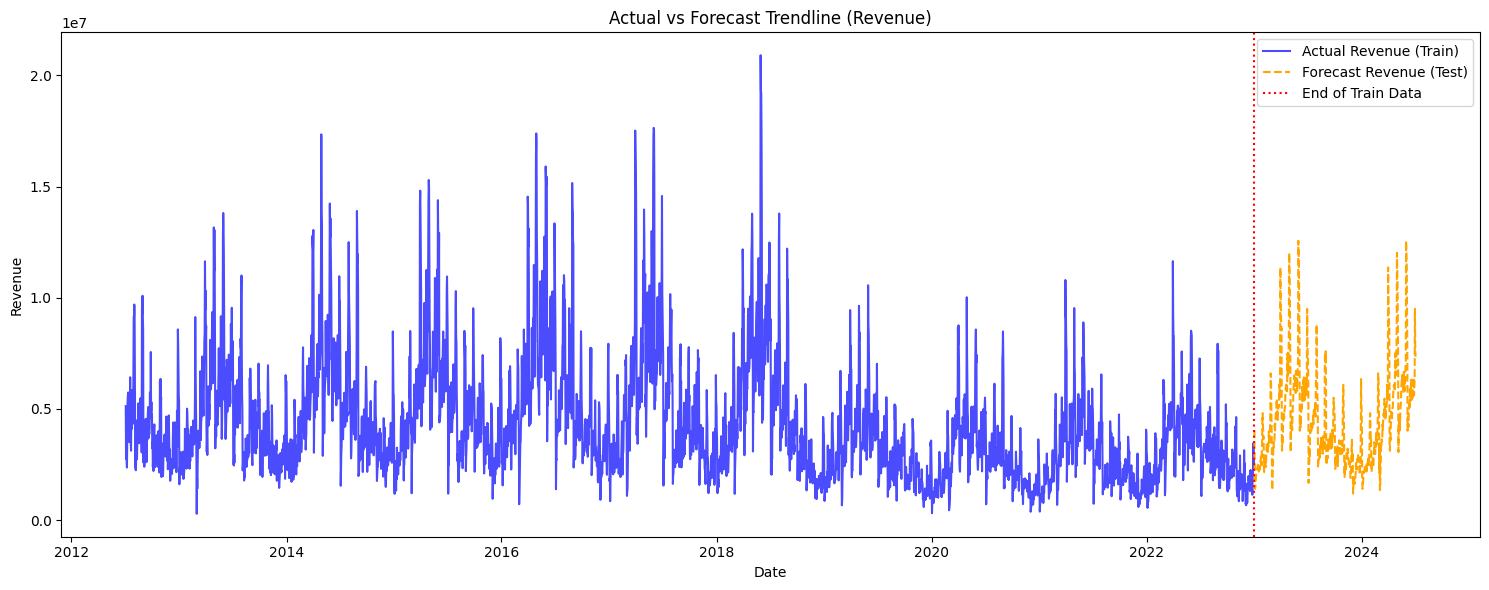

In [14]:
plt.figure(figsize=(15, 6))

# Nhóm dữ liệu theo ngày để đồ thị mượt hơn nếu có nhiều giao dịch trong một ngày
train_trend = df_train.groupby('Date')['Revenue'].sum().reset_index()
test_trend = df_test.groupby('Date')['final_revenue'].sum().reset_index()

plt.plot(train_trend['Date'], train_trend['Revenue'], label='Actual Revenue (Train)', color='blue', alpha=0.7)
plt.plot(test_trend['Date'], test_trend['final_revenue'], label='Forecast Revenue (Test)', color='orange', linestyle='--')
plt.axvline(x=train_trend['Date'].max(), color='red', linestyle=':', label='End of Train Data')

plt.title('Actual vs Forecast Trendline (Revenue)')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.tight_layout()
plt.savefig('../output/chart/actual_vs_forecast_trendline.png', dpi=300)
plt.show()
